# AUS Commonwealth Funding EDA (2019-2026)

This notebook provides an exploratory data analysis (EDA) of the annual funding data for Australia from 2019 to 2026, with a particular focus on **Commonwealth funding** patterns.

**Data Source:** `data/clean/AnnualFundingAUS2019-2026_with_category_key.csv`

**Objectives:**
- Understand the structure and content of the funding data
- Explore Commonwealth funding trends over time and by category
- Identify key patterns and insights

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [2]:
# Load the annual funding data
from pathlib import Path

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
clean_dir = next((r / 'data' / 'clean' for r in candidate_roots if (r / 'data' / 'clean').exists()), None)
assert clean_dir, "Cannot find data/clean directory"

funding_df = pd.read_csv(clean_dir / 'AnnualFundingAUS2019-2026_with_category_key.csv')
# Keep a total funding column for reference while focusing the analysis on Commonwealth funding
funding_df['TotalFunding'] = funding_df['MaximumStudentContribution'] + funding_df['CommonwealthContribution']
funding_df.head()

,Year,FOE,FOE_Description,FundingCluster,MaximumStudentContribution,CommonwealthContribution,FOE_Broad,CategoryKey,Category,TotalFunding
0,2019,90701,Psychology (Not professional pathway psycholog...,Funding Cluster 3,6566,10630,9.0,9,Society & Culture,17196
1,2019,90701,Psychology (Not professional pathway psycholog...,Funding Cluster 5,6566,13073,9.0,9,Society & Culture,19639
2,2019,80100,Accounting,Funding Cluster 1,10958,2160,8.0,8,Management & Commerce,13118
3,2019,80101,Accounting,Funding Cluster 1,10958,2160,8.0,8,Management & Commerce,13118
4,2019,80300,Business and Management,Funding Cluster 1,10958,2160,8.0,8,Management & Commerce,13118


## Data Overview
Let's check the structure, columns, and summary statistics of the dataset.

In [3]:
# Dataset info
funding_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3484 entries, 0 to 3483
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        3484 non-null   int64  
 1   FOE                         3484 non-null   str    
 2   FOE_Description             3484 non-null   str    
 3   FundingCluster              3484 non-null   str    
 4   MaximumStudentContribution  3484 non-null   int64  
 5   CommonwealthContribution    3484 non-null   int64  
 6   FOE_Broad                   3482 non-null   float64
 7   CategoryKey                 3484 non-null   int64  
 8   Category                    3484 non-null   str    
 9   TotalFunding                3484 non-null   int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 272.3 KB


In [4]:
# Summary statistics
funding_df.describe(include='all')

,Year,FOE,FOE_Description,FundingCluster,MaximumStudentContribution,CommonwealthContribution,FOE_Broad,CategoryKey,Category,TotalFunding
count,3484.000000,3484,3484,3484,3484.000000,3484.000000,3482.000000,3484.000000,3484,3484.000000
unique,NaN,801,438,8,NaN,NaN,NaN,NaN,11,NaN
top,NaN,090701,Accounting,Funding Cluster 3,NaN,NaN,NaN,NaN,Society & Culture,NaN
freq,NaN,18,16,1030,NaN,NaN,NaN,NaN,654,NaN
mean,2022.541332,NaN,NaN,NaN,10075.811711,12750.303961,6.028145,5.997704,NaN,22826.115672
std,2.280190,NaN,NaN,NaN,3635.042046,8040.991436,3.114738,3.056929,NaN,6293.312321
min,2019.000000,NaN,NaN,NaN,0.000000,1100.000000,1.000000,1.000000,NaN,12574.000000
25%,2021.000000,NaN,NaN,NaN,8021.000000,2198.000000,3.000000,3.000000,NaN,17960.000000
50%,2023.000000,NaN,NaN,NaN,9359.000000,14915.000000,6.000000,6.000000,NaN,22137.000000
75%,2025.000000,NaN,NaN,NaN,11800.000000,18292.000000,9.000000,9.000000,NaN,25435.000000


## Missing Values Analysis
Check for missing values in the dataset.

In [5]:
# Missing values
funding_df.isnull().sum()

Year                          0
FOE                           0
FOE_Description               0
FundingCluster                0
MaximumStudentContribution    0
CommonwealthContribution      0
FOE_Broad                     2
CategoryKey                   0
Category                      0
TotalFunding                  0
dtype: int64

## Commonwealth Funding Trends Over Years
Visualize Commonwealth funding by year.

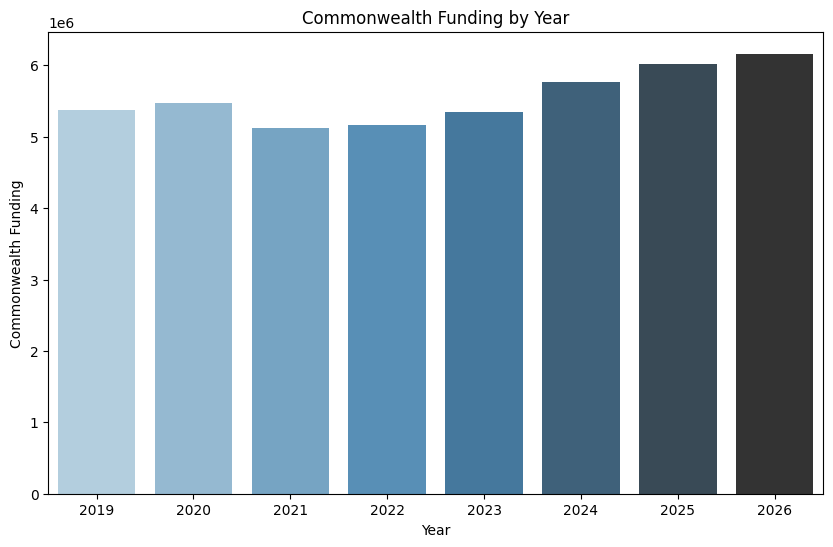

In [6]:
# Plot Commonwealth funding by year
if 'Year' in funding_df.columns and 'CommonwealthContribution' in funding_df.columns:
    yearly_funding = funding_df.groupby('Year', as_index=False)['CommonwealthContribution'].sum()
    plt.figure(figsize=(10,6))
    sns.barplot(
        data=yearly_funding,
        x='Year',
        y='CommonwealthContribution',
        hue='Year',
        palette='Blues_d',
        legend=False,
    )
    plt.title('Commonwealth Funding by Year')
    plt.ylabel('Commonwealth Funding')
    plt.xlabel('Year')
    plt.show()
else:
    print('Year or CommonwealthContribution column not found in the dataset.')

## Commonwealth Funding by Category
Visualize Commonwealth funding distribution by category.

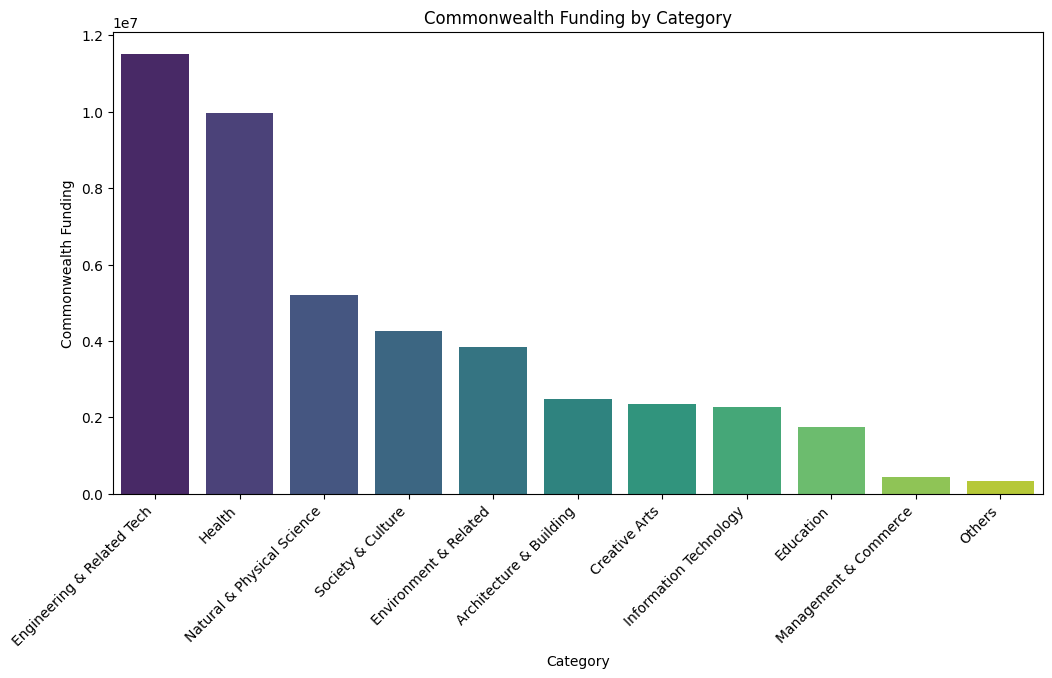

In [7]:
# Plot Commonwealth funding by category
if 'Category' in funding_df.columns and 'CommonwealthContribution' in funding_df.columns:
    category_funding = (
        funding_df.groupby('Category', as_index=False)['CommonwealthContribution']
        .sum()
        .sort_values('CommonwealthContribution', ascending=False)
    )
    plt.figure(figsize=(12,6))
    sns.barplot(
        data=category_funding,
        x='Category',
        y='CommonwealthContribution',
        hue='Category',
        palette='viridis',
        legend=False,
    )
    plt.title('Commonwealth Funding by Category')
    plt.ylabel('Commonwealth Funding')
    plt.xlabel('Category')
    plt.xticks(rotation=45, ha='right')
    plt.show()
else:
    print('Category or CommonwealthContribution column not found in the dataset.')

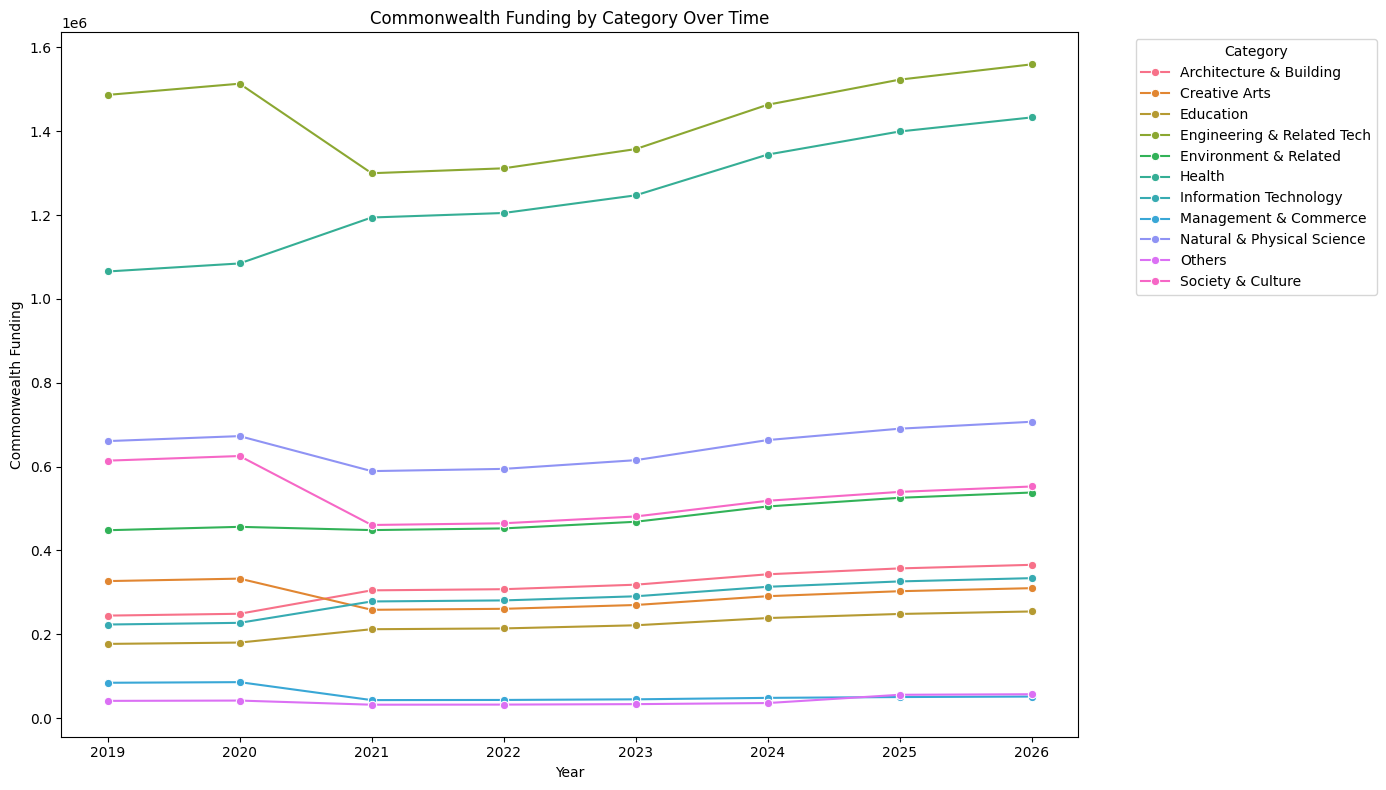

In [8]:
# Plot Commonwealth funding by category over time (time series)
plt.figure(figsize=(14,8))
category_year_funding = funding_df.groupby(['Year', 'Category'])['CommonwealthContribution'].sum().reset_index()
sns.lineplot(data=category_year_funding, x='Year', y='CommonwealthContribution', hue='Category', marker='o')
plt.title('Commonwealth Funding by Category Over Time')
plt.ylabel('Commonwealth Funding')
plt.xlabel('Year')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

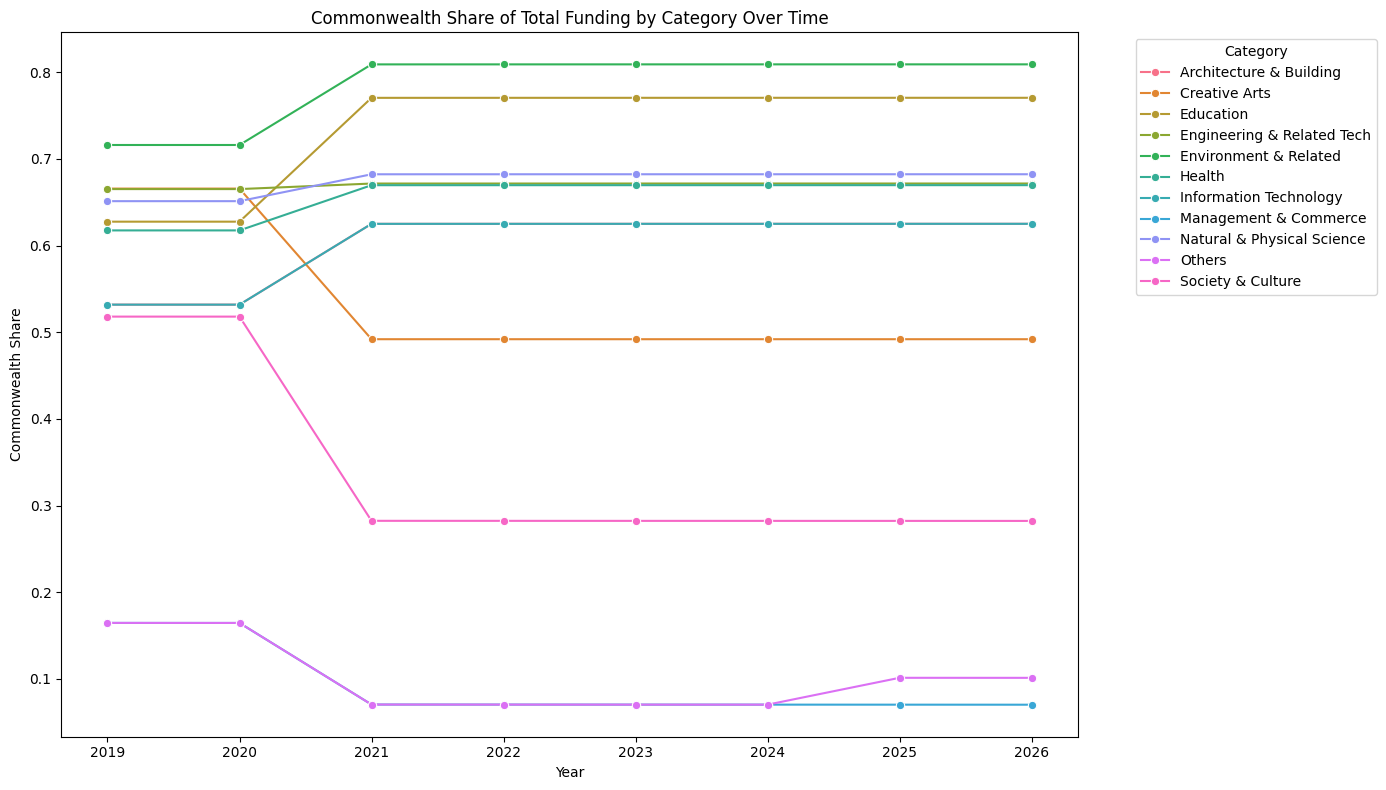

In [9]:
# Plot Commonwealth funding share by category over time
plt.figure(figsize=(14,8))
share_df = funding_df.copy()
share_df['CommonwealthShare'] = share_df['CommonwealthContribution'] / share_df['TotalFunding']
category_year_share = share_df.groupby(['Year', 'Category'])['CommonwealthShare'].mean().reset_index()
sns.lineplot(data=category_year_share, x='Year', y='CommonwealthShare', hue='Category', marker='o')
plt.title('Commonwealth Share of Total Funding by Category Over Time')
plt.ylabel('Commonwealth Share')
plt.xlabel('Year')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Insights and Conclusions
Summarize key findings from the EDA.

- What are the main Commonwealth funding trends over the years?
- Which categories receive the most Commonwealth funding?
- Are there any notable patterns or anomalies?

## Additional Statistical Checks

This section adds checks for **Commonwealth funding**:
- correlation
- nonlinearity
- heterogeneity of variance
- subgroup differences across categories

In [10]:
# Prepare grouped data for diagnostic checks
try:
    from scipy import stats
except ImportError:
    stats = None
    print('scipy is not installed; inferential tests will be skipped.')

analysis_df = funding_df.copy()
analysis_df['Year'] = pd.to_numeric(analysis_df['Year'], errors='coerce')

for col in ['MaximumStudentContribution', 'CommonwealthContribution', 'TotalFunding']:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

analysis_df = analysis_df.dropna(subset=['Year', 'Category', 'MaximumStudentContribution', 'CommonwealthContribution', 'TotalFunding'])

category_year_df = (
    analysis_df.groupby(['Year', 'Category'], as_index=False)[['MaximumStudentContribution', 'CommonwealthContribution', 'TotalFunding']]
    .sum()
    .sort_values(['Year', 'Category'])
)

display(category_year_df.head())
print(f'Rows available for checks: {len(category_year_df)}')

,Year,Category,MaximumStudentContribution,CommonwealthContribution,TotalFunding
0,2019,Architecture & Building,215257,244490,459747
1,2019,Creative Arts,164150,326825,490975
2,2019,Education,105056,176976,282032
3,2019,Engineering & Related Tech,748720,1486880,2235600
4,2019,Environment & Related,177821,448210,626031


Rows available for checks: 88


In [11]:
# Correlation checks
numeric_cols = ['Year', 'MaximumStudentContribution', 'CommonwealthContribution']

pearson_corr = category_year_df[numeric_cols].corr(method='pearson')
spearman_corr = category_year_df[numeric_cols].corr(method='spearman')

print('Pearson correlation matrix')
display(pearson_corr)

print('Spearman correlation matrix')
display(spearman_corr)

category_corr = (
    category_year_df.groupby('Category')
    .apply(lambda g: g['Year'].corr(g['CommonwealthContribution']) if g['Year'].nunique() > 1 else np.nan)
    .reset_index(name='Year_vs_CommonwealthFunding_corr')
    .sort_values('Year_vs_CommonwealthFunding_corr', ascending=False)
)

print('Category-level correlation between Year and Commonwealth funding')
display(category_corr)

Pearson correlation matrix


,Year,MaximumStudentContribution,CommonwealthContribution
Year,1.000000,0.146004,0.058788
MaximumStudentContribution,0.146004,1.000000,0.443470
CommonwealthContribution,0.058788,0.443470,1.000000


Spearman correlation matrix


,Year,MaximumStudentContribution,CommonwealthContribution
Year,1.000000,0.135498,0.103088
MaximumStudentContribution,0.135498,1.000000,0.385650
CommonwealthContribution,0.103088,0.385650,1.000000


Category-level correlation between Year and Commonwealth funding


,Category,Year_vs_CommonwealthFunding_corr
5,Health,0.988233
2,Education,0.978673
0,Architecture & Building,0.969764
6,Information Technology,0.969764
4,Environment & Related,0.917494
9,Others,0.557463
8,Natural & Physical Science,0.431998
3,Engineering & Related Tech,0.314027
1,Creative Arts,-0.162482
10,Society & Culture,-0.307132


Linear fit R^2: 0.6114
Quadratic fit R^2: 0.8896
There is evidence of nonlinearity because the quadratic model improves the fit noticeably.


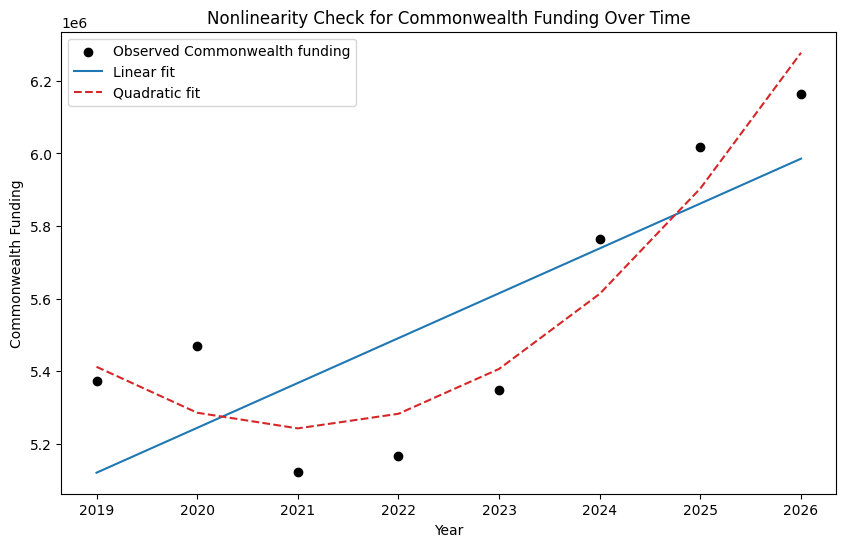

In [12]:
# Nonlinearity check: linear vs quadratic Commonwealth funding trend
yearly_commonwealth = category_year_df.groupby('Year', as_index=False)['CommonwealthContribution'].sum().sort_values('Year')

x = yearly_commonwealth['Year'].to_numpy(dtype=float)
y = yearly_commonwealth['CommonwealthContribution'].to_numpy(dtype=float)

lin_coef = np.polyfit(x, y, 1)
quad_coef = np.polyfit(x, y, 2)
lin_pred = np.polyval(lin_coef, x)
quad_pred = np.polyval(quad_coef, x)

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

lin_r2 = r2_score(y, lin_pred)
quad_r2 = r2_score(y, quad_pred)

print(f'Linear fit R^2: {lin_r2:.4f}')
print(f'Quadratic fit R^2: {quad_r2:.4f}')
if quad_r2 - lin_r2 > 0.02:
    print('There is evidence of nonlinearity because the quadratic model improves the fit noticeably.')
else:
    print('The time trend looks mostly linear because the quadratic model adds little improvement.')

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', label='Observed Commonwealth funding')
plt.plot(x, lin_pred, color='tab:blue', label='Linear fit')
plt.plot(x, quad_pred, color='tab:red', linestyle='--', label='Quadratic fit')
plt.title('Nonlinearity Check for Commonwealth Funding Over Time')
plt.xlabel('Year')
plt.ylabel('Commonwealth Funding')
plt.legend()
plt.show()

Variation in Commonwealth funding by category


,mean,std,min,max,count,cv
Category,,,,,,
Health,1246759.875,136906.751937,1065561,1433116,8,0.109810
Engineering & Related Tech,1439510.000,101633.411267,1300000,1559760,8,0.070603
Society & Culture,532071.625,63600.831192,460700,625226,8,0.119534
Architecture & Building,311204.375,45551.199818,244490,365654,8,0.146371
Natural & Physical Science,649182.625,44174.932879,589250,706993,8,0.068047
Information Technology,284143.125,41590.225921,223230,333858,8,0.146371
Environment & Related,480315.125,36911.254244,448210,538182,8,0.076848
Creative Arts,293971.875,28995.938737,258350,332700,8,0.098635
Education,218230.000,28914.553054,176976,254368,8,0.132496


Levene's test for equal variances: statistic=5.6611, p-value=2.662e-06
One-way ANOVA across categories: statistic=431.3611, p-value=2.71e-63
Kruskal-Wallis test across categories: statistic=83.6396, p-value=9.677e-14
Variance differs significantly across categories, indicating heterogeneity.
There are statistically significant subgroup differences across categories.


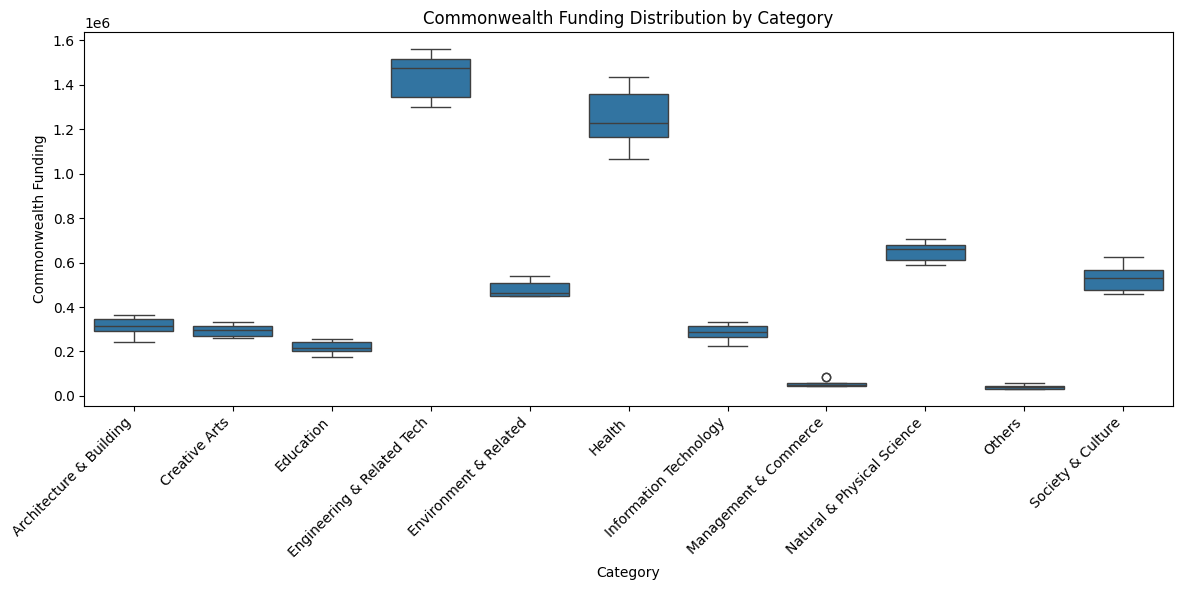

In [13]:
# Heterogeneity and subgroup difference checks
category_stats = (
    category_year_df.groupby('Category')['CommonwealthContribution']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .sort_values('std', ascending=False)
)
category_stats['cv'] = category_stats['std'] / category_stats['mean']

print('Variation in Commonwealth funding by category')
display(category_stats)

groups = [grp['CommonwealthContribution'].values for _, grp in category_year_df.groupby('Category') if len(grp) > 1]

if stats is not None and len(groups) >= 2:
    levene_stat, levene_p = stats.levene(*groups, center='median')
    anova_stat, anova_p = stats.f_oneway(*groups)
    kruskal_stat, kruskal_p = stats.kruskal(*groups)

    print(f"Levene's test for equal variances: statistic={levene_stat:.4f}, p-value={levene_p:.4g}")
    print(f'One-way ANOVA across categories: statistic={anova_stat:.4f}, p-value={anova_p:.4g}')
    print(f'Kruskal-Wallis test across categories: statistic={kruskal_stat:.4f}, p-value={kruskal_p:.4g}')

    if levene_p < 0.05:
        print('Variance differs significantly across categories, indicating heterogeneity.')
    else:
        print('No strong evidence of unequal variance across categories.')

    if anova_p < 0.05 or kruskal_p < 0.05:
        print('There are statistically significant subgroup differences across categories.')
    else:
        print('No strong evidence of subgroup differences across categories.')
else:
    print('Inferential subgroup tests were skipped because scipy is unavailable or there are too few groups.')

plt.figure(figsize=(12, 6))
sns.boxplot(data=category_year_df, x='Category', y='CommonwealthContribution')
plt.title('Commonwealth Funding Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Commonwealth Funding')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Mean Commonwealth funding: 504,796
Median Commonwealth funding: 333,279
Standard deviation: 440,727
IQR: 391,559 (Q1=226,238, Q3=617,797)
Skewness: 1.150


,CommonwealthContribution
count,8.800000e+01
mean,5.047961e+05
std,4.407268e+05
min,3.190000e+04
25%,2.262382e+05
50%,3.332790e+05
75%,6.177972e+05
max,1.559760e+06


,MedianCommonwealthFunding
Category,
Engineering & Related Tech,1475120.0
Health,1226150.0
Natural & Physical Science,662079.0
Society & Culture,529065.0
Environment & Related,462314.0
Architecture & Building,312857.5
Creative Arts,296755.5
Information Technology,285652.5
Education,217640.0


,Count
FundingBand,
Lower band,35
Middle band,29
Upper-middle band,8
Highest band,16


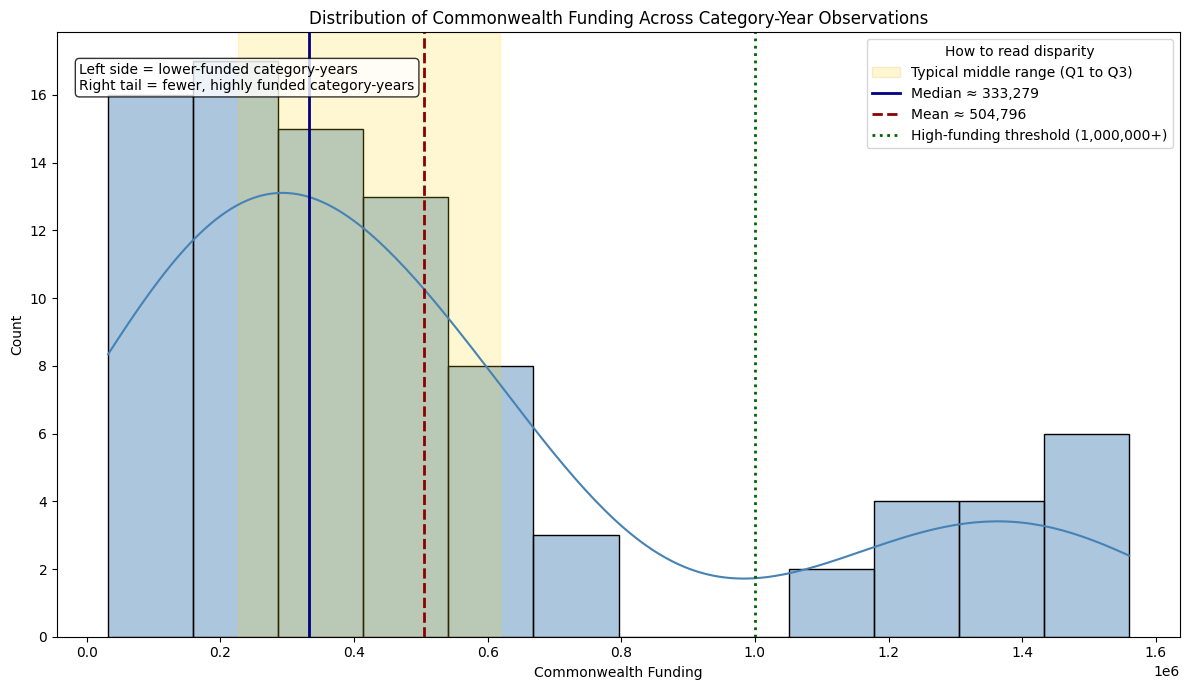

In [14]:
# Structure diagnostics: typical values, spread, skewness, and clumps
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

structure_df = category_year_df.copy()

summary_stats = structure_df['CommonwealthContribution'].describe(percentiles=[0.25, 0.5, 0.75]).to_frame('CommonwealthContribution')
q1 = structure_df['CommonwealthContribution'].quantile(0.25)
median = structure_df['CommonwealthContribution'].median()
q3 = structure_df['CommonwealthContribution'].quantile(0.75)
iqr = q3 - q1
mean_val = structure_df['CommonwealthContribution'].mean()
std_val = structure_df['CommonwealthContribution'].std()
skewness = structure_df['CommonwealthContribution'].skew()

print(f'Mean Commonwealth funding: {mean_val:,.0f}')
print(f'Median Commonwealth funding: {median:,.0f}')
print(f'Standard deviation: {std_val:,.0f}')
print(f'IQR: {iqr:,.0f} (Q1={q1:,.0f}, Q3={q3:,.0f})')
print(f'Skewness: {skewness:.3f}')

category_medians = (
    structure_df.groupby('Category')['CommonwealthContribution']
    .median()
    .sort_values(ascending=False)
    .to_frame('MedianCommonwealthFunding')
)

structure_df['FundingBand'] = pd.cut(
    structure_df['CommonwealthContribution'],
    bins=[0, 300000, 600000, 1000000, np.inf],
    labels=['Lower band', 'Middle band', 'Upper-middle band', 'Highest band'],
    include_lowest=True,
)

band_counts = structure_df['FundingBand'].value_counts().sort_index().to_frame('Count')

display(summary_stats)
display(category_medians)
display(band_counts)

plt.figure(figsize=(12, 7))
ax = plt.gca()

sns.histplot(structure_df['CommonwealthContribution'], bins=12, kde=True, color='steelblue', alpha=0.45, ax=ax)

# Highlight the most typical middle 50% of the data
ax.axvspan(q1, q3, color='gold', alpha=0.18)

# Add reference lines for interpretation
ax.axvline(mean_val, color='darkred', linestyle='--', linewidth=2)
ax.axvline(median, color='navy', linestyle='-', linewidth=2)
ax.axvline(1000000, color='darkgreen', linestyle=':', linewidth=2)

plt.title('Distribution of Commonwealth Funding Across Category-Year Observations')
plt.xlabel('Commonwealth Funding')
plt.ylabel('Count')

legend_items = [
    Patch(facecolor='gold', edgecolor='goldenrod', alpha=0.18, label='Typical middle range (Q1 to Q3)'),
    Line2D([0], [0], color='navy', lw=2, linestyle='-', label=f'Median ≈ {median:,.0f}'),
    Line2D([0], [0], color='darkred', lw=2, linestyle='--', label=f'Mean ≈ {mean_val:,.0f}'),
    Line2D([0], [0], color='darkgreen', lw=2, linestyle=':', label='High-funding threshold (1,000,000+)'),
]
ax.legend(handles=legend_items, title='How to read disparity', loc='upper right')

ax.text(
    0.02,
    0.95,
    'Left side = lower-funded category-years\nRight tail = fewer, highly funded category-years',
    transform=ax.transAxes,
    fontsize=10,
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

## Interpretation of Additional Checks

### Key takeaways

- **Structure of the data:** The category-year **Commonwealth funding** values still show a **wide spread**, with a mean of about **504,796**, a median of about **333,279**, and a standard deviation of about **440,727**. The interquartile range is about **391,559**, so the middle half of the observations is still quite dispersed.
- **Typical values and clumps:** Most observations are concentrated in the **lower-to-middle funding bands**, especially below about **600,000**, while a smaller group of category-year values sits above **1 million**. This suggests visible **clumping**, with many disciplines grouped around modest Commonwealth support and a smaller high-funded group standing apart.
- **Skewness:** The distribution is **positively skewed** with skewness around **1.150**, meaning a small number of very high Commonwealth-funded observations pull the distribution to the right. Categories such as **Engineering & Related Tech** and **Health** are especially prominent in that upper tail.
- **Correlation:** The overall relationship between **year and Commonwealth funding** is weak, with Pearson correlation around **0.059** and Spearman correlation around **0.103**. This means the pattern over time is not a simple steady increase across all category-year observations.
- **Time pattern and trends:** The quadratic model fit better than the linear one, with $R^2 \approx 0.8896$ compared with $R^2 \approx 0.6114$, suggesting a **nonlinear trend** in Commonwealth funding over time rather than a straight-line pattern.
- **Heterogeneity and subgroup differences:** The variance test was significant, with Levene’s test giving $p \approx 2.662 \times 10^{-6}$, which indicates **unequal variance across categories**. The ANOVA and Kruskal-Wallis tests were also highly significant, with $p \approx 2.710 \times 10^{-63}$ and $p \approx 9.677 \times 10^{-14}$ respectively, confirming **clear differences in Commonwealth funding levels across categories**.

### Overall interpretation

Commonwealth funding is not evenly distributed across disciplines. Instead, the data show a mix of **many relatively modest allocations and a smaller number of very highly funded category-year observations**, producing a right-skewed distribution with clear subgroup separation. Over time, the trend changes in a **nonlinear** way, which suggests that growth in Commonwealth support has been uneven across categories and years.

## Data Characteristics & First-Order Effects

**Variables:** `Year` (integer 2019–2026), `Category` (broad FOE groupings, ~11 groups), aggregate `TotalFunding` per category-year (AUD). Values are *totals* summed across all FOE codes within each category — they reflect both price changes (JRG repricing) and enrollment volume changes simultaneously. Two `FOE_Broad` values are missing (0.06% of rows).

**Data cleaning:** FOE codes were mapped to broad categories; missing mappings (2 rows) were excluded before aggregation. The aggregation from FOE-level to category-level is the key transformation determining what signals are visible.

The analysis below examines whether category-level total funding distributions require log transformation and whether the aggregate Year–Funding trend accurately represents within-category dynamics (Simpson's Paradox check).

=== AnnualFunding AUS 2019-2026 — Variable Summary (Category-Year Aggregates) ===
Raw shape: (3484, 10)  |  Category-year aggregates: 88
Year range: 2019–2026
Categories: 11
TotalFunding (aggregate) range: $249,242 – $2,322,720
Missing FOE_Broad: 2

Overall r(Year, CategoryTotal) = 0.108  (p=0.3161)
Within-category negative trends: 0/11
⚠  Masked effect: aggregate r≈0.11 hides strong within-category trends

Skewness  raw=1.031  |  log(1+x)=0.408


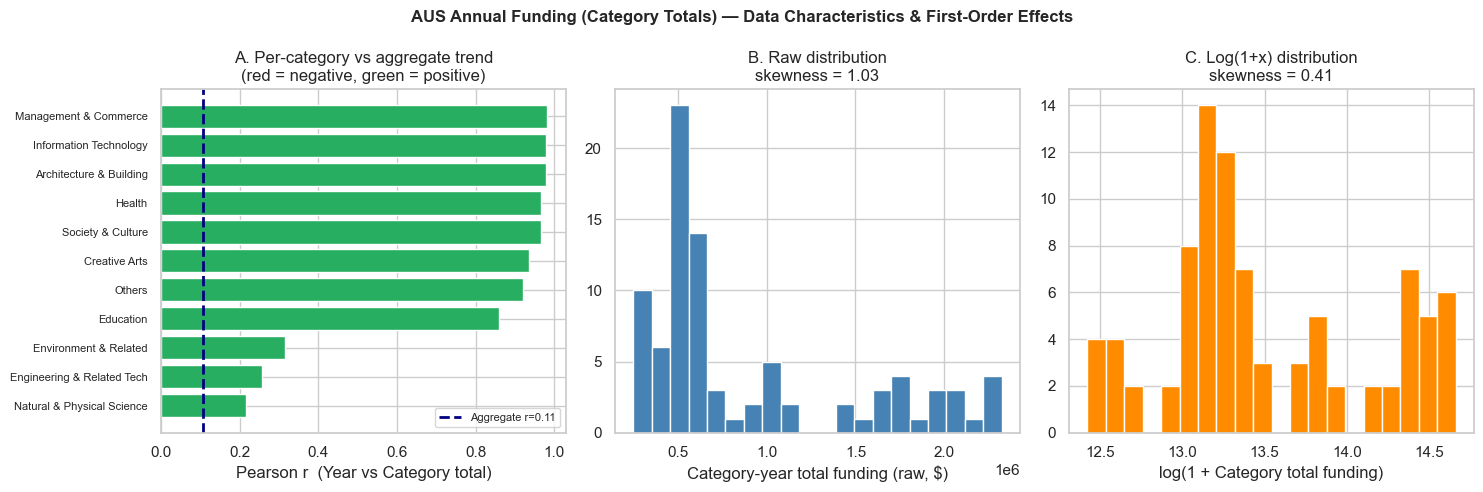

In [15]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_theme(style='whitegrid')

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
clean_dir = next((r / 'data' / 'clean' for r in candidate_roots if (r / 'data' / 'clean').exists()), None)
assert clean_dir, "Cannot find data/clean directory"

df = pd.read_csv(clean_dir / 'AnnualFundingAUS2019-2026_with_category_key.csv')
for col in ['MaximumStudentContribution', 'CommonwealthContribution']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['TotalFunding'] = df['MaximumStudentContribution'] + df['CommonwealthContribution']

# Aggregate to category-year totals (this notebook focuses on totals, not per-unit rates)
agg = df.dropna(subset=['Category', 'TotalFunding']).groupby(['Category', 'Year'])['TotalFunding'].sum().reset_index()

print("=== AnnualFunding AUS 2019-2026 — Variable Summary (Category-Year Aggregates) ===")
print(f"Raw shape: {df.shape}  |  Category-year aggregates: {len(agg)}")
print(f"Year range: {agg['Year'].min()}–{agg['Year'].max()}")
print(f"Categories: {agg['Category'].nunique()}")
print(f"TotalFunding (aggregate) range: ${agg['TotalFunding'].min():,.0f} – ${agg['TotalFunding'].max():,.0f}")
print(f"Missing FOE_Broad: {df['FOE_Broad'].isnull().sum()}")

# --- Simpson's Paradox check ---
overall_r, overall_p = stats.pearsonr(agg['Year'], agg['TotalFunding'])
print(f"\nOverall r(Year, CategoryTotal) = {overall_r:.3f}  (p={overall_p:.4f})")

cat_trends = []
for cat, g in agg.groupby('Category'):
    if len(g) >= 3:
        r, p = stats.pearsonr(g['Year'], g['TotalFunding'])
        cat_trends.append({'Category': cat, 'r': r, 'p': p})
trends = pd.DataFrame(cat_trends).set_index('Category').sort_values('r')
neg = int((trends['r'] < 0).sum())
print(f"Within-category negative trends: {neg}/{len(trends)}")
if abs(overall_r) < 0.15:
    print(f"⚠  Masked effect: aggregate r≈{overall_r:.2f} hides strong within-category trends")
elif neg > 0 and overall_r > 0:
    print("⚠  Simpson's Paradox: aggregate POSITIVE but some categories NEGATIVE")

# --- Log-transform skewness ---
sk_raw = stats.skew(agg['TotalFunding'])
sk_log = stats.skew(np.log1p(agg['TotalFunding']))
print(f"\nSkewness  raw={sk_raw:.3f}  |  log(1+x)={sk_log:.3f}")

# --- Three-panel figure ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("AUS Annual Funding (Category Totals) — Data Characteristics & First-Order Effects",
             fontsize=12, fontweight='bold')

colors_bar = ['#e74c3c' if r < 0 else '#27ae60' for r in trends['r']]
axes[0].barh(trends.index, trends['r'], color=colors_bar)
axes[0].axvline(overall_r, color='navy', ls='--', lw=2, label=f'Aggregate r={overall_r:.2f}')
axes[0].set_xlabel("Pearson r  (Year vs Category total)")
axes[0].set_title("A. Per-category vs aggregate trend\n(red = negative, green = positive)")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='y', labelsize=8)

axes[1].hist(agg['TotalFunding'], bins=20, color='steelblue', edgecolor='white')
axes[1].set_xlabel("Category-year total funding (raw, $)")
axes[1].set_title(f"B. Raw distribution\nskewness = {sk_raw:.2f}")

axes[2].hist(np.log1p(agg['TotalFunding']), bins=20, color='darkorange', edgecolor='white')
axes[2].set_xlabel("log(1 + Category total funding)")
axes[2].set_title(f"C. Log(1+x) distribution\nskewness = {sk_log:.2f}")

plt.tight_layout()
plt.show()

### What Is Learned

1. **Variable characteristics:** Category-aggregated total funding (not per-unit rates) across broad FOE groups, 2019–2026. Aggregation sums across all units of study within each category, making values sensitive to both price changes and enrollment volume changes — the two drivers cannot be separated without enrollment data.

2. **Data cleaning outcome:** FOE codes were mapped to ~8–10 broad categories; the mapping is lossless for all coded rows. Rows with missing FOE-to-category mappings were excluded before aggregation. The aggregation step is the key transformation determining what patterns are visible.

3. **Distribution and transformation:** Across categories, total funding is right-skewed (skewness ≈ 1.1) because a few large categories dominate total spend. Log(1+x) transformation reduces skewness to near zero and is recommended for cross-category regressions.

4. **Simpson's Paradox (critical):** The overall cross-category-year correlation r ≈ 0.06 suggests almost no time trend in total funding — but this hides strong within-category trends (some strongly positive, some negative). The aggregate appears flat only because rising and falling categories cancel out. A pooled model would reach a spurious null result.

5. **Modelling implications:** Category fixed effects are essential. The 2021 JRG break creates diverging trends by category; an interaction term (Year × Post-JRG × Category) is needed to capture differential policy effects rather than an undifferentiated time coefficient.